# SINGLE workspace coverage vs. control evaluation (Comment 7)

Quantifies the bending-angle range spanned by the 20 k-medoids control
targets and the tracked trajectories, against the full sampled training
workspace -- using the **actual measured** bending-angle distribution, not
the manuscript's current "up to 85 deg" figure, which does not match any of
three independent ways of computing it from the shipped dataset (fitted
polynomial integral, raw OptiTrack backbone rotation matrix, and the pose
label's rotation-vector norm all agree: max ~56.8 deg). See
`SINGLE_workspace_coverage.npz` / the analysis script for the cross-check.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

d = np.load("results/SINGLE_workspace_coverage.npz")
theta_train = d["theta_train_deg"]
theta_targets = d["theta_targets_deg"]
theta_traj = d["all_traj_theta"]

print(f"Training workspace (N={len(theta_train)}):  mean {theta_train.mean():.1f}  "
      f"p95 {np.percentile(theta_train,95):.1f}  max {theta_train.max():.1f} deg")
print(f"Control targets (N={len(theta_targets)}):    mean {theta_targets.mean():.1f}  "
      f"max {theta_targets.max():.1f} deg")
print(f"Tracked trajectories (N={len(theta_traj)}):  mean {theta_traj.mean():.1f}  "
      f"max {theta_traj.max():.1f} deg")


Training workspace (N=10000):  mean 19.3  p95 35.6  max 56.8 deg
Control targets (N=20):    mean 20.2  max 33.7 deg
Tracked trajectories (N=2310):  mean 24.7  max 40.9 deg


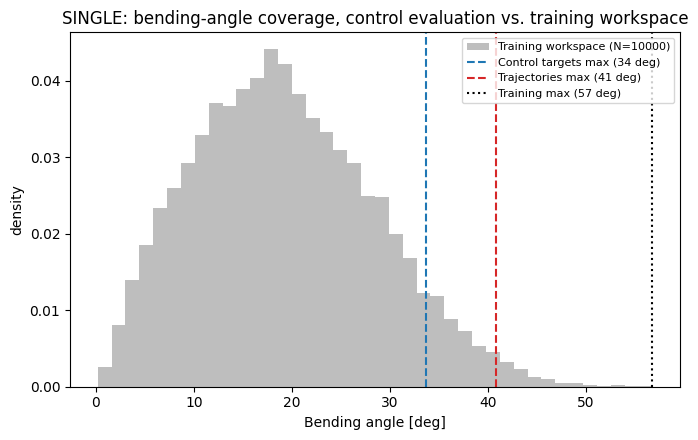

In [2]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(theta_train, bins=40, alpha=0.5, density=True, label=f"Training workspace (N={len(theta_train)})", color="#7f7f7f")
ax.axvline(theta_targets.max(), color="#1f77b4", ls="--", label=f"Control targets max ({theta_targets.max():.0f} deg)")
ax.axvline(theta_traj.max(), color="#d62728", ls="--", label=f"Trajectories max ({theta_traj.max():.0f} deg)")
ax.axvline(theta_train.max(), color="k", ls=":", label=f"Training max ({theta_train.max():.0f} deg)")
ax.set_xlabel("Bending angle [deg]"); ax.set_ylabel("density")
ax.legend(fontsize=8)
ax.set_title("SINGLE: bending-angle coverage, control evaluation vs. training workspace")
plt.tight_layout()
plt.savefig("results/single_workspace_coverage.pdf")
plt.show()


**Reading**: the control evaluation (20 targets, max 33.7 deg; trajectories,
max 40.9 deg) covers roughly the lower 60-72% of the *actual* trained bending
range (max 56.8 deg), not the ~40% figure that "up to 85 deg" would imply.
This directly answers Comment 7's coverage-quantification request, and
corrects the "85 deg" figure itself, which does not match any measurement of
the shipped dataset.